In [2]:
import tensorflow as tf
import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
!pip install ImageDataGenerator

ERROR: Could not find a version that satisfies the requirement ImageDataGenerator (from versions: none)
ERROR: No matching distribution found for ImageDataGenerator


In [5]:
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
img = image.load_img('/content/train/cat.jpeg',target_size= (200,200))

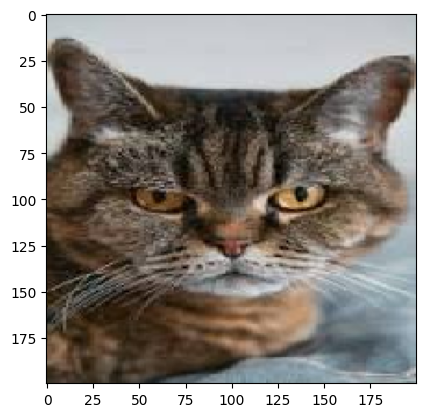

In [7]:
plt.imshow(img)

In [8]:
type(img)

PIL.Image.Image

In [31]:
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='constant'

)

In [32]:
img = image.img_to_array(img)

In [33]:
type(img)

numpy.ndarray

In [34]:
img.shape

(200, 200, 3)

In [35]:
input_batch = img.reshape(1,200,200,3)

In [36]:
import os
os.makedirs('aug', exist_ok=True)
i = 0
for output in datagen.flow(input_batch,batch_size = 1, save_to_dir = 'aug'):
  i = i+1

  if i == 10:
    break

Without data augmentation

In [37]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [40]:
import os
import shutil
import random

# Base path for the downloaded dataset from the previous cell
original_dataset_base_path = path # 'path' variable is from the previous kagglehub.dataset_download call
base_original_images_dir = os.path.join(original_dataset_base_path, 'train') # This directory contains 'cats' and 'dogs' subfolders

# Define the new base directory for our organized data
base_dir = 'data'

# Define the number of images for each split and class
num_train_per_class = 1000
num_validation_per_class = 500
num_test_per_class = 500

# Create the main 'data' directory if it doesn't exist
os.makedirs(base_dir, exist_ok=True)

# Create train, validation, test directories within 'data'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(validation_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Create 'cats' and 'dogs' subdirectories within each split
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
test_cats_dir = os.path.join(test_dir, 'cats')
test_dogs_dir = os.path.join(test_dir, 'dogs')

os.makedirs(train_cats_dir, exist_ok=True)
os.makedirs(train_dogs_dir, exist_ok=True)
os.makedirs(validation_cats_dir, exist_ok=True)
os.makedirs(validation_dogs_dir, exist_ok=True)
os.makedirs(test_cats_dir, exist_ok=True)
os.makedirs(test_dogs_dir, exist_ok=True)

# Get all cat and dog filenames from their respective original subdirectories
original_cat_images_dir = os.path.join(base_original_images_dir, 'cats')
original_dog_images_dir = os.path.join(base_original_images_dir, 'dogs')

cat_fnames = os.listdir(original_cat_images_dir)
dog_fnames = os.listdir(original_dog_images_dir)

# Shuffle the filenames to ensure random splits
random.shuffle(cat_fnames)
random.shuffle(dog_fnames)

# Split filenames for each category
train_cat_fnames = cat_fnames[:num_train_per_class]
validation_cat_fnames = cat_fnames[num_train_per_class : num_train_per_class + num_validation_per_class]
test_cat_fnames = cat_fnames[num_train_per_class + num_validation_per_class : num_train_per_class + num_validation_per_class + num_test_per_class]

train_dog_fnames = dog_fnames[:num_train_per_class]
validation_dog_fnames = dog_fnames[num_train_per_class : num_train_per_class + num_validation_per_class]
test_dog_fnames = dog_fnames[num_train_per_class + num_validation_per_class : num_train_per_class + num_validation_per_class + num_test_per_class]

print(f"Number of training cat images: {len(train_cat_fnames)}")
print(f"Number of training dog images: {len(train_dog_fnames)}")
print(f"Number of validation cat images: {len(validation_cat_fnames)}")
print(f"Number of validation dog images: {len(validation_dog_fnames)}")
print(f"Number of test cat images: {len(test_cat_fnames)}")
print(f"Number of test dog images: {len(test_dog_fnames)}")

# Function to copy files
def copy_files(source_fnames, source_dir, destination_dir):
    for fname in source_fnames:
        src = os.path.join(source_dir, fname)
        dst = os.path.join(destination_dir, fname)
        shutil.copyfile(src, dst)

print("\nCopying training cat images...")
copy_files(train_cat_fnames, original_cat_images_dir, train_cats_dir)
print("Copying training dog images...")
copy_files(train_dog_fnames, original_dog_images_dir, train_dogs_dir)

print("\nCopying validation cat images...")
copy_files(validation_cat_fnames, original_cat_images_dir, validation_cats_dir)
print("Copying validation dog images...")
copy_files(validation_dog_fnames, original_dog_images_dir, validation_dogs_dir)

print("\nCopying test cat images...")
copy_files(test_cat_fnames, original_cat_images_dir, test_cats_dir)
print("Copying test dog images...")
copy_files(test_dog_fnames, original_dog_images_dir, test_dogs_dir)

print("\nDataset organization complete!")
print(f"Total files copied: {len(train_cat_fnames) + len(train_dog_fnames) + len(validation_cat_fnames) + len(validation_dog_fnames) + len(test_cat_fnames) + len(test_dog_fnames)}")

# Verify counts in the new directories
print("\nVerifying counts in new directories:")
print(f"Train Cats: {len(os.listdir(train_cats_dir))}")
print(f"Train Dogs: {len(os.listdir(train_dogs_dir))}")
print(f"Validation Cats: {len(os.listdir(validation_cats_dir))}")
print(f"Validation Dogs: {len(os.listdir(validation_dogs_dir))}")
print(f"Test Cats: {len(os.listdir(test_cats_dir))}")
print(f"Test Dogs: {len(os.listdir(test_dogs_dir))}")

Number of training cat images: 1000
Number of training dog images: 1000
Number of validation cat images: 500
Number of validation dog images: 500
Number of test cat images: 500
Number of test dog images: 500

Copying training cat images...
Copying training dog images...

Copying validation cat images...
Copying validation dog images...

Copying test cat images...
Copying test dog images...

Dataset organization complete!
Total files copied: 4000

Verifying counts in new directories:
Train Cats: 1000
Train Dogs: 1000
Validation Cats: 500
Validation Dogs: 500
Test Cats: 500
Test Dogs: 500


In [41]:
import cv2
import os
import random
import numpy as np

In [42]:
mydir = '/content/data/train'

In [43]:
categories = ['cats','dogs']

In [45]:
data = []

for i in categories:
  folder_path = os.path.join(mydir,i)
  label = categories.index(i)
  for img in os.listdir(folder_path):
    img_path = os.path.join(folder_path,img)
    img_arr = cv2.imread(img_path)
    img_arr = cv2.resize(img_arr,(200,200))

    data.append([img_arr,label])

In [46]:
random.shuffle(data)

In [47]:
X =[]
y =[]
for i in data:
  X.append(i[0])
  y.append(i[1])

In [48]:
y = np.array(y)

In [49]:
X = np.array(X)

In [50]:
X.shape

(2000, 200, 200, 3)

In [51]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation

In [55]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation = 'relu',input_shape = (200,200,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32,(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
model.compile(loss='binary_crossentropy',optimizer ='rmsprop',metrics = ['accuracy'])

In [54]:
model.fit(X,y,epochs = 5,validation_split =0.1)

Epoch 1/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.5706 - loss: 52.4967 - val_accuracy: 0.5300 - val_loss: 1.1089
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.6156 - loss: 1.7406 - val_accuracy: 0.5850 - val_loss: 0.6916
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6906 - loss: 3.3016 - val_accuracy: 0.5800 - val_loss: 1.1011
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.7228 - loss: 1.3501 - val_accuracy: 0.6300 - val_loss: 0.8520
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.7161 - loss: 1.5757 - val_accuracy: 0.5200 - val_loss: 5.4836


Cats-dogs-with-data-augmentation

In [57]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [58]:
batch_size = 16

#this is the augmentation configuration we will use for training
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

#this is the augmentation configuration we will use for testing:
#only rescaling
test_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/data/train',
    target_size = (200,200),
    batch_size = batch_size,
    class_mode = 'binary'
)

validation_generator = test_datagen.flow_from_directory(
    '/content/data/validation',
    target_size = (200,200),
    batch_size = batch_size,
    class_mode = 'binary'
)


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [59]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation = 'relu',input_shape = (200,200,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32,(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model.compile(loss='binary_crossentropy',optimizer ='rmsprop',metrics = ['accuracy'])

In [62]:
model.fit(
    train_generator,
    steps_per_epoch = 2000 // batch_size,
    epochs = 5,
    validation_data = validation_generator,
    validation_steps = 800 // batch_size
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.5380 - loss: 0.7485 - val_accuracy: 0.5325 - val_loss: 0.6914
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.6100 - loss: 0.6736 - val_accuracy: 0.6087 - val_loss: 0.6319
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.6640 - loss: 0.6367 - val_accuracy: 0.6687 - val_loss: 0.5709
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.6790 - loss: 0.6069 - val_accuracy: 0.6862 - val_loss: 0.5832
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.7005 - loss: 0.5745 - val_accuracy: 0.5888 - val_loss: 0.9310


In [74]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/data/test/cats/cat.10432.jpg'
img = image.load_img(img_path, target_size=(200, 200))
img_array = image.img_to_array(img)

# Rescale the image like it was done during training
img_array = img_array / 255.0

# Expand dimensions to create a batch of size 1
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("It's a dog!")
else:
    print("It's a cat!")

print(f"Prediction score: {prediction[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
It's a dog!
Prediction score: 0.8367367386817932
